# Sentiment Analysis using Bert
The goal of sentiment analysis is to identify what users appreciate and what they dislike in product reviews. Specifically, we aim to analyze the textual content of reviews to determine whether the expressed sentiment aligns with the numerical rating provided by the user.

This process allows us to detect which aspects of the product are commonly praised or criticized, offering a more nuanced and qualitative understanding than what is provided by the average rating (avg_rating) alone.

Furthermore, sentiment analysis enables the definition of a coherence metric between the textual content and the assigned rating. This metric can be used to:

- Clean the dataset by identifying suspicious or inconsistent reviews;

- Highlight potential rating errors (e.g., high rating but negative text);

- Improve the overall interpretability of user feedback.

## Install and import the dependencies

In [1]:
!pip install --upgrade datasets fsspec
!rm -rf ~/.cache/huggingface/datasets/*
!pip install transformers[torch] datasets accelerate evaluate
!pip install transformers datasets scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 39.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [2]:
from google.colab import drive
import json
import os
import torch
import transformers
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, BertModel
from datasets import load_dataset
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import random

import re
import unicodedata
import html
from tqdm import tqdm
import zipfile
from collections import Counter
from transformers import EarlyStoppingCallback
import seaborn as sns
from torch.utils.data import random_split

from torch.utils.data import DataLoader
from transformers import default_data_collator


print(transformers.__version__)

drive.mount('/content/drive', force_remount=True)

4.54.0
Mounted at /content/drive


## Function

In [3]:
# Helper function for extracting the raiting in various formats
def extract_rating(rating_field):
    if isinstance(rating_field, dict):
        if '$numberInt' in rating_field:
            try:
                return int(rating_field['$numberInt'])
            except:
                return None
        elif '$numberDouble' in rating_field:
            try:
                return int(round(float(rating_field['$numberDouble'])))
            except:
                return None
        else:
            return None
    elif isinstance(rating_field, (int, float)):
        return int(rating_field)
    else:
        return None

# Will change the value rating in sentiment
def label_sentiment(rating):
    if rating in [4, 5]:
        return 2  # Positive
    elif rating == 3:
        return 1  # Neutral
    elif rating in [1, 2]:
        return 0  # Negative
    else:
        return None  # Case of corrupted Data

# Will count the unique product in all the reviews
def count_unique_products_from_reviews(json_path):
    product_ids = set()
    with open(json_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                review = json.loads(line)
                product_id = review.get("product")
                if product_id:
                    product_ids.add(product_id)
            except:
                continue
    print(f"Number of unique products: {len(product_ids)}")

# This function retrieves the first product reviews whose word count is below 'max_words'.
# Once the number of collected reviews reaches 'max_examples',
# it returns the corresponding list of product IDs.
def find_short_reviews(json_path, max_words=10, max_examples=10):
    short_reviews = []
    with open(json_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                review = json.loads(line)
                body = review.get("body", "").strip()
                if body and len(body.split()) <= max_words:
                    short_reviews.append({
                        'product': review.get("product"),
                        'rating': review.get("rating"),
                        'body': body
                    })
                    if len(short_reviews) >= max_examples:
                        break
            except:
                continue

    print(f"Found {len(short_reviews)} short reviews (≤ {max_words} words):\n")
    for idx, rev in enumerate(short_reviews, 1):
        print(f"[{idx}] Rating: {rev['rating']}, Product: {rev['product']}")
        print(f"→ Review: {rev['body']}\n")

# Retrieves the first reviews with the different tag described below.
# Verified - Non verified ---- Helpful - Not Helpful
def find_reviews_by_flags(json_path, max_per_category=5):
    verified_reviews = []
    unverified_reviews = []
    helpful_reviews = []
    non_helpful_reviews = []

    with open(json_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                review = json.loads(line)

                body = review.get("body", "").strip()
                rating = review.get("rating", "")
                id = review.get("_id", "")
                product = review.get("product", "")
                verified = review.get("verified", None)
                helpful_raw = review.get("helpful", 0)

                # Numerical extraction of the helpful field
                if isinstance(helpful_raw, dict):
                    helpful = int(helpful_raw.get("$numberInt", 0))
                else:
                    helpful = int(helpful_raw)

                # Filter and assign to the various categories
                if verified is True and len(verified_reviews) < max_per_category:
                    verified_reviews.append((product, rating, body, id))
                elif verified is False and len(unverified_reviews) < max_per_category:
                    unverified_reviews.append((product, rating, body, id))

                if helpful > 0 and len(helpful_reviews) < max_per_category:
                    helpful_reviews.append((product, rating, body, helpful, id))
                elif helpful == 0 and len(non_helpful_reviews) < max_per_category:
                    non_helpful_reviews.append((product, rating, body, helpful, id))

                # Stop if all the lists are full
                if (len(verified_reviews) >= max_per_category and
                    len(unverified_reviews) >= max_per_category and
                    len(helpful_reviews) >= max_per_category and
                    len(non_helpful_reviews) >= max_per_category):
                    break
            except Exception as e:
                continue

    # Output
    print("\n🔹 Verified reviews:")
    for prod, rate, body, id in verified_reviews:
        print(f"Id_review : {id}, Product: {prod}, Rating: {rate}, Verified: ✅\n→ {body}\n")

    print("\n🔸 Unverified reviews:")
    for prod, rate, body, id in unverified_reviews:
        print(f"Id_review : {id}, Product: {prod}, Rating: {rate}, Verified: ❌\n→ {body}\n")

    print("\n📈 Helpful reviews (helpful > 0):")
    for prod, rate, body, id in helpful_reviews:
        print(f"Id_review : {id}, Product: {prod}, Rating: {rate}, Helpful: {h}\n→ {body}\n")

    print("\n📉 Non-helpful reviews (helpful = 0 or missing):")
    for prod, rate, body, id in non_helpful_reviews:
        print(f"Id_review : {id}, Product: {prod}, Rating: {rate}, Helpful: {h}\n→ {body}\n")


# These function will plot the montlhy trend using the rating reviews per month
#############################################################
def parse_rating(rating_field):
    if isinstance(rating_field, dict):
        return int(rating_field.get('$numberInt', 0))
    try:
        return int(rating_field)
    except:
        return None

def group_reviews_by_month(json_path, selected_product=None):
    monthly_ratings = defaultdict(list)
    product_counts = defaultdict(int)

    with open(json_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                review = json.loads(line)
                product = review.get("product")
                if not product:
                    continue
                rating = parse_rating(review.get("rating"))
                if not rating:
                    continue
                date_str = review.get("date")
                if not date_str:
                    continue
                date = datetime.strptime(date_str, "%Y-%m-%d")
                month_key = date.strftime("%Y-%m")

                # We count the reviews to select a product if not specified.
                product_counts[product] += 1

                if selected_product and product != selected_product:
                    continue

                monthly_ratings[month_key].append(rating)
            except:
                continue

    if not selected_product:
        # If a product has not been passed, select one randomly from the most reviewed ones.
        selected_product = sorted(product_counts.items(), key=lambda x: x[1], reverse=True)[0][0]
        print(f"[🎯] Prodotto selezionato automaticamente: {selected_product}")

    # Calculate average per month
    monthly_avg = {
        month: sum(ratings) / len(ratings)
        for month, ratings in sorted(monthly_ratings.items())
    }

    return selected_product, monthly_avg

def plot_monthly_trend(monthly_avg, product_id):
    months = list(monthly_avg.keys())
    averages = list(monthly_avg.values())

    plt.figure(figsize=(15, 7))
    plt.plot(months, averages, marker='o', linestyle='-', color='royalblue')
    plt.xticks(rotation=45, fontsize = 9)
    plt.title(f"Monthly rating trend for the product {product_id}")
    plt.xlabel("Month")
    plt.ylabel("Average rating")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#############################################################

# Return reviews based on a specific product and target month.
# The function stops when it reaches the maximum number of results (max_results).
# For example, if target_month = 4 and max_results = 5, it will process until month = 9.
def get_reviews_for_month(json_path, product_id, target_month="2011-04", max_results=5):
    matching_reviews = []

    with open(json_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                review = json.loads(line)
                if review.get("product") != product_id:
                    continue

                date_str = review.get("date", "")
                if not date_str:
                    continue
                date = datetime.strptime(date_str, "%Y-%m-%d")
                review_month = date.strftime("%Y-%m")

                if review_month != target_month:
                    continue

                # Take only the importat informatic
                review_info = {
                    "date": date_str,
                    "rating": review.get("rating"),
                    "verified": review.get("verified"),
                    "helpful": review.get("helpful", 0),
                    "body": review.get("body", "").strip()
                }
                matching_reviews.append(review_info)

                if len(matching_reviews) >= max_results:
                    break

            except Exception as e:
                continue

    # Output
    print(f"\n🔎 Prime {len(matching_reviews)} reviews for the product '{product_id}' nel mese {target_month}:\n")
    for i, rev in enumerate(matching_reviews, 1):
        print(f"[{i}] 📅 {rev['date']} | ⭐ {rev['rating']} | ✅ Verified: {rev['verified']} | 👍 Helpful: {rev['helpful']}")
        print(f"→ {rev['body']}\n")


################################################################################
# This function will clean the review by removing the unnecessarily text
def clean_review_ita(text):

    # Decode HTML entities (&quot;)
    text = html.unescape(text)

    # Normalization of typographic quotation marks and apostrophes
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")

    # Keep / or - if it is between numbers (e.g. 7/8 or 7-8)
    text = re.sub(r'(\d+)\s*[/\-]\s*(\d+)', r'\1 o \2', text)

    # Removes strange symbols but not accented letters
    text = ''.join(c for c in text if (
        c.isprintable() and
        (unicodedata.category(c)[0] != "C") and
        not unicodedata.category(c).startswith('So')
    ))

    # Normalize the excessive repetitions of exclamation or question marks.
    text = re.sub(r'([!?])\1+', r'\1', text)

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # Spaces around punctuation
    text = re.sub(r'\s([?.!"](?:\s|$))', r'\1', text)

    # Replaces two or more consecutive points with three dots of suspension.
    text = re.sub(r'\.{2,}', '...', text)

    return text.strip()

def clean_reviews_dataset(raw_path, cleaned_path, max_examples=5):
    if os.path.exists(cleaned_path):
        print(f"✅ Clean file already exist: {cleaned_path}")
        return cleaned_path

    print("- Starting cleaning of the reviews - ...")
    count_total, count_cleaned = 0, 0
    examples = []  # List where save few example of cleaning

    with open(raw_path, 'r', encoding='utf-8') as infile, \
         open(cleaned_path, 'w', encoding='utf-8') as outfile:

        for line in infile:
            try:
                review = json.loads(line)
                body = review.get("body", "")

                if body and clean_review_ita(body):
                    cleaned = clean_review_ita(body)
                    if len(examples) < max_examples:
                        examples.append((body, cleaned))
                    review["body"] = cleaned
                    count_cleaned += 1

                outfile.write(json.dumps(review, ensure_ascii=False) + '\n')
                count_total += 1

            except Exception as e:
                continue

    print(f"✅ Cleaning completed. Totals: {count_total} | Cleaned: {count_cleaned}")
    print(f"💾 File saved in: {cleaned_path}")

    # MOSTRA ESEMPI
    print("\n🔍 Example of modified reviews:")
    for i, (before, after) in enumerate(examples, 1):
        print(f"\n🔸 Esempio {i}")
        print("👈 Before:", before)
        print("👉 After: ", after)

    return cleaned_path

################################################################################

# Distribution of the token length
def plot_token_length_distribution(json_path, max_reviews=None):
    token_lengths = []

    with open(json_path, 'r', encoding='utf-8') as file:
        for i, line in enumerate(tqdm(file, desc="📦 Review analysis")):
            if max_reviews and i >= max_reviews:
                break
            try:
                review = json.loads(line)
                text = review.get("body", "").strip()
                if text:
                    tokens = tokenizer.tokenize(text)
                    token_lengths.append(len(tokens))
            except:
                continue  # ignore malformed lines

    # Define the bins: from 0 to 1000 in intervals of 100, then a final bin 1000+
        bins = list(range(0, 1100, 100)) + [float('inf')]
        labels = [f"{i}-{i+100}" for i in range(0, 1000, 100)] + ["1000+"]

        # Count the occurrences for each range
        bin_counts = [0] * len(labels)
        for length in token_lengths:
            for i in range(len(bins) - 1):
                if bins[i] <= length < bins[i + 1]:
                    bin_counts[i] += 1
                    break

        # Plot
        plt.figure(figsize=(12, 6))
        plt.bar(labels, bin_counts, color='teal', edgecolor='black')
        plt.xticks(rotation=45)
        plt.title("Distribution of review length (BERT tokens)")
        plt.xlabel("Token interval")
        plt.ylabel("Number of reviews")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print(f"Number of reviews analyzed: {len(token_lengths)}")
        print(f"Average: {np.mean(token_lengths):.2f} token | Max: {max(token_lengths)} | Min: {min(token_lengths)}")

        return token_lengths

## Analysis of the Dataset and Pre-processing

Analyzing the dataset is essential for filtering out reviews that do not provide meaningful insight into the product.  
The ultimate goal of this project is to develop a model capable of extracting **positive and negative insights** from Amazon reviews, revealing product **strengths and weaknesses**.

---

Review Structure

Each review contains the following attributes:

- `_id`: Unique review identifier  
- `product`: Product ID that the review refers to  
- `title`: Title of the review  
- `author-id`: Unique identifier of the review author  
- `author-name`: Name of the review author  
- `date`: Date the review was written  
- `rating`: Star rating (1 to 5)  
- `helpful`: Number of users who found the review useful  
- `verified`: Whether the purchase was verified  
- `body`: Full text content of the review  

---

What Can Be Done with These Attributes?

The first step is to identify which attributes are most useful for extracting meaningful insights.

- `helpful` and `verified` are valuable for filtering out **fake reviews**.  
  Reviews from fake accounts might be overly positive or negative, often intended to promote or sabotage products.  
  By focusing on reviews marked as helpful and verified, we can better ensure **genuine context**, improving the precision of the insights extracted from the review texts.

- This enables us to understand which product aspects are frequently discussed and how they are perceived by real users.  
  Aggregating these insights provides a more reliable summary of the product’s strengths and weaknesses.

- If using a simple BERT model to predict review sentiment based on rating alone, **all reviews** (even fake ones) could be included.  
  However, this might introduce **bias** and reduce the reliability of model predictions.

---

In [4]:
json_file_path = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews.json'
CLEANED_PATH = "/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews_clean.json"
RELEVANT_PATH = "/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews_relevant.json"
count_unique_products_from_reviews(json_file_path)

Number of unique products: 62502


Review Length Distribution After Tokenization

This plot shows the distribution of review lengths after tokenization using BERT-compatible transformers.  
From the graph, we observe that the majority of reviews fall below 128 tokens.

This insight suggests that we can safely set the tokenizer's `max_length` parameter to **128 tokens**, truncating any excess.  
The assumption here is that the most relevant and informative content tends to appear at the beginning of the review, allowing us to preserve the key context while maintaining computational efficiency.


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

📦 Analisi recensioni: 100000it [01:53, 883.92it/s]


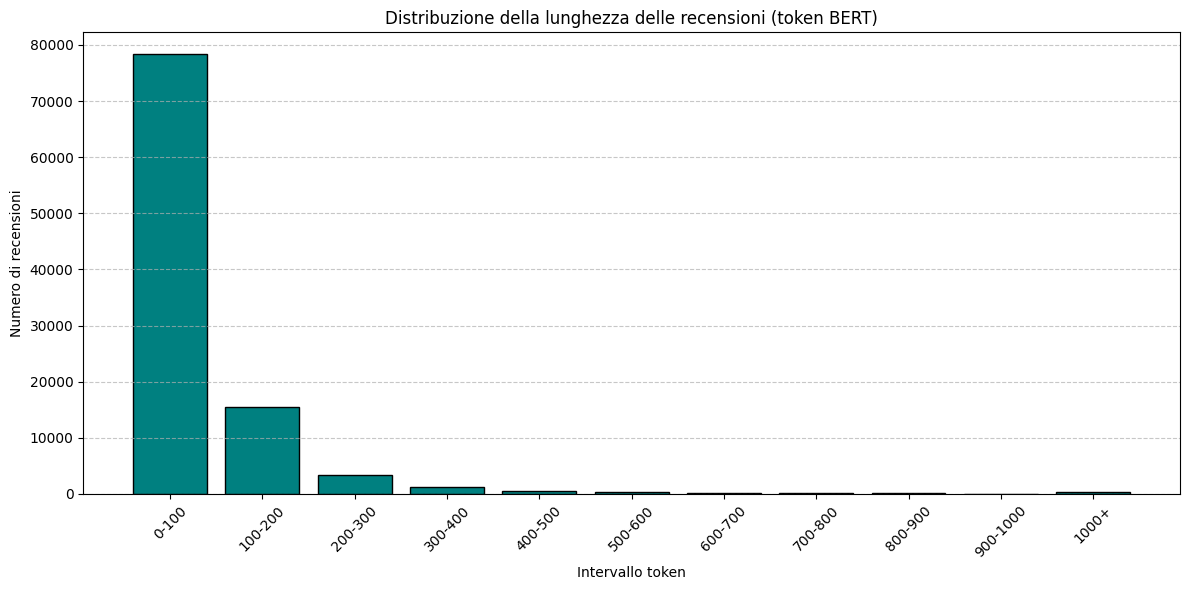

📊 Numero di recensioni analizzate: 100000
🧮 Media: 80.70 token | Max: 6420 | Min: 1


In [ ]:
# Inizializza il tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

token_lengths = plot_token_length_distribution(json_file_path, max_reviews=100000)

Class Distribution – Imbalanced Labels

As shown in this pie chart, the distribution of sentiment classes is noticeably imbalanced.  
This kind of skew is common in review datasets, where positive feedback tends to dominate.

Such imbalance can significantly affect model training, leading to:
- Poor generalization for minority classes (e.g., negative reviews)
- Biased predictions toward majority classes

To address this, we might consider:
- **Resampling strategies** (e.g., oversampling negatives, undersampling positives)
- **Class weights** in the loss function to penalize errors on underrepresented classes more heavily
- **Data augmentation** or synthetic sample generation for rare cases

Taking this into account early can greatly improve the robustness and fairness of the sentiment classifier.


Numero recensioni per sentiment: {1: 100461, 2: 60360, 3: 116247, 4: 358883, 5: 1352903}


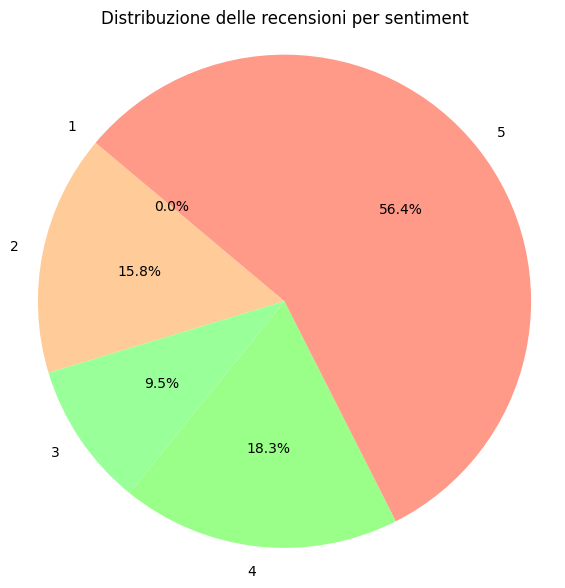

In [ ]:
def count_sentiments_from_json(json_path, sentiment_counts):

    with open(json_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                review = json.loads(line)
                rating = extract_rating(review.get("rating"))
                label = label_sentiment(rating)

                if rating is not None:
                    sentiment_counts[rating] += 1
            except Exception as e:
                continue

    return sentiment_counts

def plot_sentiment_pie(sentiment_counts, labels):
    counts = [sentiment_counts.get(i, 1) for i in range(5)]

    plt.figure(figsize=(7,7))
    plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#ffcc99','#99ff99', '#99ff88', '#ff9988'])
    plt.title('Distribution of reviews by sentiment')
    plt.axis('equal')  # To maintain the circle perfetly circle
    plt.show()

counts = count_sentiments_from_json(json_file_path, {1:0, 2:0, 3:0, 4:0, 5:0})
print(f"Number of reviews by sentiment: {counts}")
plot_sentiment_pie(counts, ['1', '2', '3','4', '5'])

After using the function that classify in positive, negative and neutral.

Numero recensioni per sentiment: {0: 160821, 1: 116247, 2: 1711786}


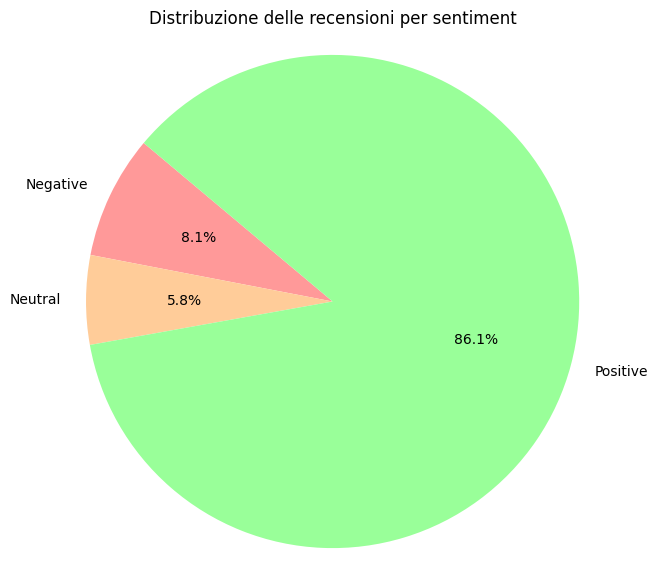

In [ ]:
counts = count_sentiments_from_json(json_file_path, {0:0, 1:0, 2:0})
print(f"Number of reviews by sentiment: {counts}")

plot_sentiment_pie(counts, ['Negative', 'Neutral', 'Positive'])

Tokenization Insight – 128 Tokens May Be Enough

From these reviews, we can observe that users tend to express their main thoughts within the first 128 tokens.  
This suggests that setting the tokenizer's maximum length to **128 tokens** could be a practical choice.

By truncating after this threshold, we retain the core content while reducing computational load.  
The assumption is that the early part of the review contains the most informative and sentiment-rich expressions, making it suitable for models like BERT to extract meaningful signals.


In [ ]:
import textwrap

# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# File path
json_path = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews.json'

max_len = 128
num_esempi = 10

esempi = []
with open(json_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            review = json.loads(line)
            text = review.get('body', '')
            rating = review.get('rating')
            if not text:
               continue

            # Tokenization without padding/truncation
            tokens = tokenizer.encode(text, add_special_tokens=True)
            if len(tokens) > max_len:
                esempi.append((len(tokens), text.strip()))

            if len(esempi) >= num_esempi:
                break
        except:
            continue

print(f"\n📚 EXAMPLES OF REVIEWS WITH MORE THAN {max_len} TOKEN:\n")
for i, (length, txt) in enumerate(esempi, 1):
    print(f"🔹 Example {i} — Token: {length} - Rating :{rating} \n{textwrap.fill(txt, width=100)}\n{'-'*80}")

Token indices sequence length is longer than the specified maximum sequence length for this model (710 > 512). Running this sequence through the model will result in indexing errors



📚 ESEMPI DI RECENSIONI CON PIÙ DI 128 TOKEN:

🔹 Esempio 1 — Token: 257 - Rating :{'$numberInt': '1'} 
Non ho mai scritto una recensione in vita mia ma per questo gioco sento proprio il bisogno di
scriverci qualcosa. Parto consigliando a tutti di non acquistare questo gioco perché BUTTATE i
vostri i soldi. Sono arrivato a questa conclusione semplicemente perché che tu sia bravo o meno non
importa, e il gioco che decide per te, tra 8/9 gol a partita o errori assurdi fatti dalla cpu il tuo
“giocare” passa in secondo piano. Ormai credo che la EA preferisca arricchirsi con vendite di giochi
e fifa points senza pensare minimamente al gamplay o a rendere il prodotto giocabile. Gioco a Fifa
da ormai 7-8 anni e credo che questo sia il peggiore di tutti e sono molto deluso. Detto questo
auguri a tutte le persone che compreranno questo gioco di divertirsi.
--------------------------------------------------------------------------------
🔹 Esempio 2 — Token: 226 - Rating :{'$numberInt': '1'} 
Uno 

In [ ]:
find_short_reviews(json_file_path, max_words=2, max_examples=5)

Found 5 short reviews (≤ 2 words):

[1] Rating: {'$numberInt': '5'}, Product: B07DMJPV31
→ Review: Fantastico!!!!

[2] Rating: {'$numberInt': '4'}, Product: B07DMJPV31
→ Review: Prodotto ottimo

[3] Rating: {'$numberInt': '5'}, Product: B07DMJPV31
→ Review: Gioco perfetto

[4] Rating: {'$numberInt': '5'}, Product: B07DMJPV31
→ Review: Solito Fifa

[5] Rating: {'$numberInt': '4'}, Product: B07DMJPV31
→ Review: divertente



In [ ]:
find_reviews_by_flags(json_file_path, max_per_category=5)


🔹 Verified reviews:
Id_review : R5U4GZKVIS0NK, Product: B07DMJPV31, Rating: {'$numberInt': '1'}, Verified: ✅
→ Non ho mai scritto una recensione in vita mia ma per questo gioco sento proprio il bisogno di scriverci qualcosa. Parto consigliando a tutti di non acquistare questo gioco perché BUTTATE i vostri i soldi. Sono arrivato a questa conclusione semplicemente perché che tu sia bravo o meno non importa, e il gioco che decide per te, tra 8/9 gol a partita o errori assurdi fatti dalla cpu il tuo “giocare” passa in secondo piano. Ormai credo che la EA preferisca arricchirsi con vendite di giochi e fifa points senza pensare minimamente al gamplay o a rendere il prodotto giocabile. Gioco a Fifa da ormai 7-8 anni e credo che questo sia il peggiore di tutti e sono molto deluso. Detto questo auguri a tutte le persone che compreranno questo gioco di divertirsi.

Id_review : RSJ27FXLJ5Z7B, Product: B07DMJPV31, Rating: {'$numberInt': '1'}, Verified: ✅
→ Uno dei peggiori se non il peggior gioco

ValueError: too many values to unpack (expected 4)

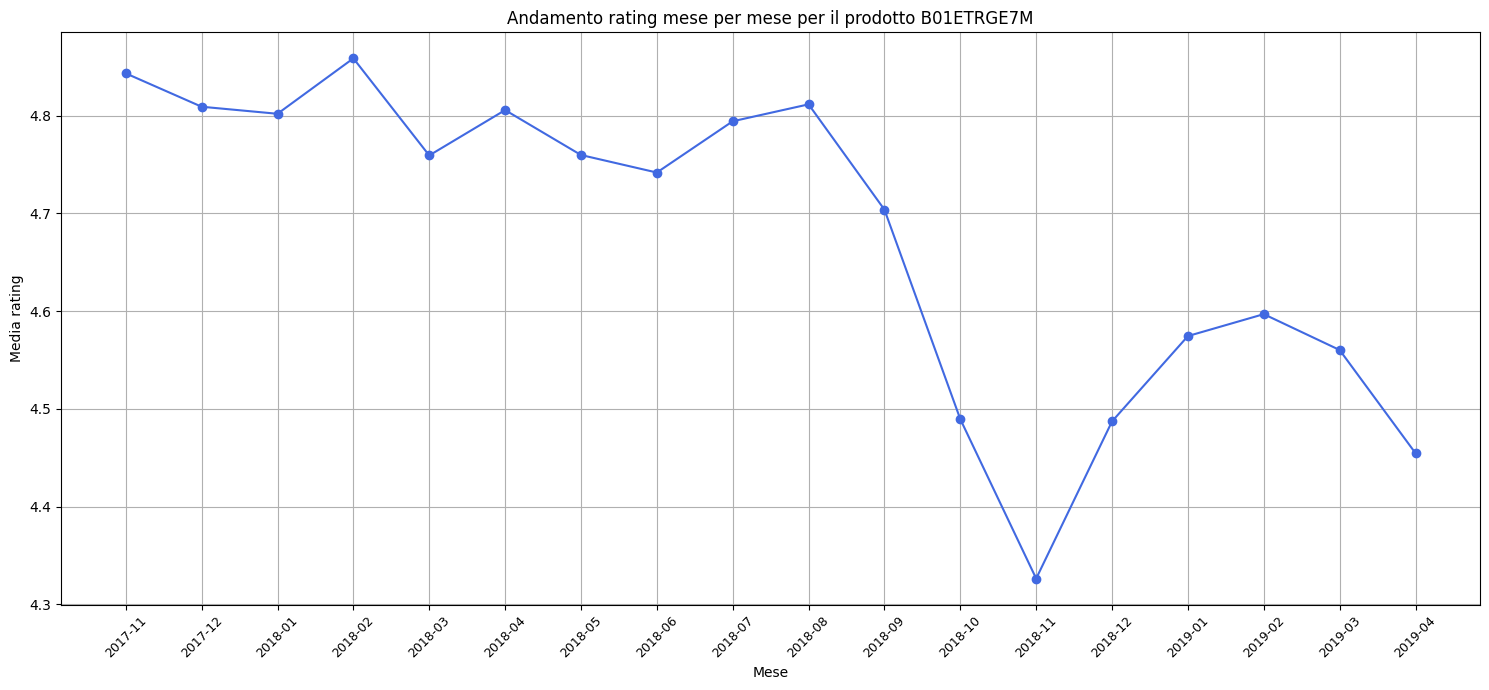

In [ ]:
product_id, monthly_avg = group_reviews_by_month(json_file_path, "B01ETRGE7M")
plot_monthly_trend(monthly_avg, product_id)

In [ ]:
product_id = "B01ETRGE7M"
get_reviews_for_month(json_file_path, product_id, target_month="2018-11", max_results=5)


🔎 Prime 5 recensioni per il prodotto 'B01ETRGE7M' nel mese 2018-11:

[1] 📅 2018-11-19 | ⭐ {'$numberInt': '3'} | ✅ Verified: True | 👍 Helpful: {'$numberInt': '21'}
→ UPDATE: Dopo qualche settimana dalla mia recensione critica (1 stella), un upgrade sembra avere risolto parecchi problemi di buffering. Le trasmissioni non si interrompono così spesso.
Porto la mia recensione da 1 a 3 stelle.

Acquistato allo scorso Black Friday, avrei fatto meglio a desistere.
La connessione, sebbene sia stabile nella stanza (a 5 metri dal router) con gli altri device lì presenti, continua a saltare e rende sgradevole la visione.
Non succede solo con Le app non native (come Netflix), ma persino con la app di Prime Video.
Lo avevo comprato per mettere anche Prime Video sulla TV principale, l'ho relegato come "coso di emergenza" in quella della camera da letto.
Ho un altro dongle della concorrenza in una stanza molto più distante e lì la visione è perfetta.
Ah, "saltava" e si bloccava anche su un'altra TV (

In [ ]:
get_reviews_for_month(json_file_path, product_id, target_month="2018-02", max_results=5)


🔎 Prime 5 recensioni per il prodotto 'B01ETRGE7M' nel mese 2018-02:

[1] 📅 2018-02-04 | ⭐ {'$numberInt': '5'} | ✅ Verified: True | 👍 Helpful: {'$numberInt': '107'}
→ Ho una TV led da 40', perfetta per le mie esigenze, comprata nel 2012, quindi no Smart. Questa Fire Stick l'ha trasformata in una smart tv a tutti gli effetti. Si connette immediatamente, la usiamo soprattutto per netflix (ma anche prime a seconda dei film) e la qualità video è full hd, nitidissima nonostante non abbia ancora (purtroppo) la fibra a casa. L'ho usata anche con spotify con ottima soddisfazione, idem con Silk per navigare. Unica noia l'uso del telecomando per digitare sulla tastiera virtuale. Sarebbe ideale poter abbinare una tastiera bluetooth. In ogni caso un ottimo prodotto, per guinta pagato la metà grazie ad un'offerta. L'ho regalata anche ai miei genitori che la usano regolarmente.
Molto soddisfatto.

[2] 📅 2018-02-20 | ⭐ {'$numberInt': '5'} | ✅ Verified: True | 👍 Helpful: {'$numberInt': '0'}
→ FANTASTI

After the cleaning of the reviews we can try to see if the dataset is cleaned and saved correctly using the function 'clean_reviews_dataset'

In [ ]:
cleaned_file = clean_reviews_dataset(json_file_path, CLEANED_PATH)

✅ File pulito già presente: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews_clean.json


Try to use only the relevant reviews using the virified tag, the min_length and helpful.

In [ ]:
# 🔍 Filtro di recensioni poco informative
def is_review_informative(review: dict, min_words=5, min_length=20):
    body = review.get("body", "")
    verified = review.get("verified", False)
    helpful = review.get("helpful", 0)

    # Scarta se troppo corta o con poche parole
    if len(body.strip()) < min_length or len(body.strip().split()) < min_words:
        return False

    # Scarta se non verificata
    if not verified:
        return False

    # Scarta se nessuno l'ha trovata utile
    if helpful == 0:
        return False

    return True

# 🔄 Funzione principale aggiornata
def clean_reviews_dataset(raw_path, cleaned_path, max_examples=5):
    if os.path.exists(cleaned_path):
        print(f"✅ Clean file already exist: {cleaned_path}")
        return cleaned_path

    print("- Starting cleaning of the reviews - ...")
    count_total, count_cleaned = 0, 0
    examples = []

    with open(raw_path, 'r', encoding='utf-8') as infile, \
         open(cleaned_path, 'w', encoding='utf-8') as outfile:

        for line in infile:
            try:
                review = json.loads(line)
                original_body = review.get("body", "")

                # 🔹 Pulizia testo
                cleaned_body = clean_review_ita(original_body)
                review["body"] = cleaned_body

                # 🔹 Filtraggio recensioni disturbanti
                if not is_review_informative(review, min_length=10):
                    count_total += 1
                    continue

                count_cleaned += 1

                # 🔹 Salva qualche esempio
                if len(examples) < max_examples:
                    examples.append((original_body, cleaned_body))

                outfile.write(json.dumps(review, ensure_ascii=False) + '\n')

            except Exception as e:
                continue

            count_total += 1

    print(f"✅ Cleaning completed. Totals: {count_total} | Saved after cleaning: {count_cleaned}")
    print(f"💾 File saved in: {cleaned_path}")

    # MOSTRA ESEMPI
    print("\n🔍 Example of modified and accepted reviews:")
    for i, (before, after) in enumerate(examples, 1):
        print(f"\n🔸 Esempio {i}")
        print("👈 Before:", before)
        print("👉 After: ", after)

    return cleaned_path

cleaned_file = clean_reviews_dataset(json_file_path, RELEVANT_PATH)

- Starting cleaning of the reviews - ...
✅ Cleaning completed. Totals: 1988854 | Saved after cleaning: 1740794
💾 File saved in: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews_relevant.json

🔍 Example of modified and accepted reviews:

🔸 Esempio 1
👈 Before: Non ho mai scritto una recensione in vita mia ma per questo gioco sento proprio il bisogno di scriverci qualcosa. Parto consigliando a tutti di non acquistare questo gioco perché BUTTATE i vostri i soldi. Sono arrivato a questa conclusione semplicemente perché che tu sia bravo o meno non importa, e il gioco che decide per te, tra 8/9 gol a partita o errori assurdi fatti dalla cpu il tuo “giocare” passa in secondo piano. Ormai credo che la EA preferisca arricchirsi con vendite di giochi e fifa points senza pensare minimamente al gamplay o a rendere il prodotto giocabile. Gioco a Fifa da ormai 7-8 anni e credo che questo sia il peggiore di tutti e sono molto deluso. Detto questo auguri a tutte le persone c

See if the function works.

In [ ]:
target_id = "R1E3KM3V2T55Y"  # Sobstituite the real ID

# Find the review with the corresponding ID
found = False
with open(json_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            review = json.loads(line)
            if review.get("_id") == target_id:
                found = True
                print(f"\n🔹 Review trovata con _id = {target_id}:\n")
                print(json.dumps(review, indent=2, ensure_ascii=False))

                # Applica filtro
                result = is_review_informative(review)
                print(f"\n🔎 Risultato filtro: {'Informativa' if result else 'NON informativa'}")
                break
        except Exception as e:
            continue

if not found:
    print(f"Nessuna review trovata con _id = {target_id}")


🔹 Review trovata con _id = R1E3KM3V2T55Y:

{
  "_id": "R1E3KM3V2T55Y",
  "product": "B07DMJPV31",
  "title": "Amazon impeccabile, EA SPORTS FIFA pensa solo a fare cassa...",
  "author-id": "AEJ2GT7HCC2YW27MGZKJRXQ24GNA",
  "author-name": "BioCosmesi",
  "date": "2018-09-28",
  "rating": {
    "$numberInt": "1"
  },
  "helpful": {
    "$numberInt": "6"
  },
  "verified": false,
  "body": "Gli sviluppatori pensano solo ad implementare il FUT che è dove la gente magari compra pacchetti e loro guadagnano, dal lato giocabilità semplice ed online solo a fare partite normali penso sia cambiato del 1%, non lavorano più sulla grafica e quant'altro e questo dispiace, hanno girato la loro attenzione solo sul guadagno, capisco che devono rientrare della spesa per avere la licenza Champions, però da giocatore di Fifa dal 98 questa è la prima delusione ......\n- l'arbitro fischia la fine anche se ti trovi a tu per tu con il portiere.\n- c'è sempre io momentum.\n- fuorigioco che molte volte non c'è.

What Do the Analyses Reveal?

Let's start by summarizing a few key findings:

- **First Point**: Fake reviews are notoriously difficult to detect.  
  One of the few reliable ways to filter them out is by checking whether the review is *verified*.  
  A verified purchase increases our confidence that the reviewer actually bought the product—unlike scammers who may rely on automated bots.  
  To further strengthen this filter, we can also use the *helpful* metric, selecting reviews that were marked as useful by other users.

- **Second Point**: Using multiple datasets allows us to compare how the model performs across different data sources.  
  This helps assess whether the model's predictions improve or degrade depending on the dataset used, and provides insight into how the model “reasons” or adapts to various input distributions.


## Extract information and tokenize it

In [ ]:
# Configure tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# Set the folders
DATA_PATH = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews.json'
OUTPUT_DIR = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/processed_blocks'
os.makedirs(OUTPUT_DIR, exist_ok=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenization Strategy for Amazon Reviews

As shown in the histogram, Amazon reviews vary significantly in length — many are short, while others are quite long.

To avoid losing important context and stay within BERT's maximum input limit of **512 tokens**, we can take two different approaches:

- **Option 1**: Increase the `max_length` parameter to 512, assuming that most of the relevant context is contained within the first 512 tokens.
- **Option 2**: Split each review into smaller chunks, run predictions on each chunk separately, and then average the results for a consolidated sentiment score.

In our case, based on the histogram, **using the first method may be sufficient**.  
We'll evaluate later whether switching strategies or refining this approach leads to better performance.

Next, let's look at the “Analysis” chapter of the dataset to explore examples of longer reviews.


In [ ]:
# This function is used to save the dataset and not overload the memory. But is very slow
# then we will try another apporch.
def preprocess_and_save_blocks(input_path, tokenizer, output_dir, block_size=100000, max_length=128):
    texts, labels = [], []
    block_num = 0
    processed = 0

    with open(input_path, 'r', encoding='utf-8') as file:
        for i, line in enumerate(file):
            try:
                review = json.loads(line)
                text = review.get("body", "").strip()
                rating = extract_rating(review.get("rating"))
                label = label_sentiment(rating)

                if text and label is not None:
                    texts.append(text)
                    labels.append(label)
                    processed += 1
            except:
                continue

            # Appena raggiungi un blocco intero
            if len(texts) == block_size:
                block_path = os.path.join(output_dir, f'block_{block_num}.pt.zip')

                # 🔍 Se il file esiste già, salta
                if os.path.exists(block_path):
                    print(f"⏩ Block {block_num} already exists, skipping...")
                else:
                    encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt")
                    # Salvataggio file temporaneo
                    torch.save({
                        'input_ids': encodings['input_ids'],
                        'attention_mask': encodings['attention_mask'],
                        'labels': torch.tensor(labels)
                    }, block_path)

                    # Comprimilo in .zip
                    zip_path = block_path + ".zip"
                    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                        zipf.write(block_path, arcname=os.path.basename(block_path))
                    os.remove(block_path)  # elimina il .pt originale per risparmiare spazio

                    print(f"✅ Block {block_num} salvato e compresso: {zip_path}")

                block_num += 1
                texts, labels = [], []

      # Salva eventuale blocco finale
        if texts:
            block_path = os.path.join(output_dir, f'block_{block_num}.pt.zip')
            if os.path.exists(block_path):
                print(f"⏩ Final block {block_num} already exists, skipping...")
            else:
                encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt")
                torch.save({
                    'input_ids': encodings['input_ids'],
                    'attention_mask': encodings['attention_mask'],
                    'labels': torch.tensor(labels)
                }, block_path)

                zip_path = block_path + ".zip"
                with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                    zipf.write(block_path, arcname=os.path.basename(block_path))
                os.remove(block_path)

                print(f"✅ Final block {block_num} saved with {len(texts)} reviews.")

    print(f"🎯 Preprocessing completed. Reviews processed: {processed}")

preprocess_and_save_blocks(DATA_PATH, tokenizer, OUTPUT_DIR)

✅ Block 0 salvato e compresso: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/processed_blocks/block_0.pt.zip.zip
✅ Block 1 salvato e compresso: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/processed_blocks/block_1.pt.zip.zip
✅ Block 2 salvato e compresso: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/processed_blocks/block_2.pt.zip.zip


KeyboardInterrupt: 

Function that maybe extracts from zip files for training.

In [ ]:
import os
import zipfile
import torch

def load_block_from_zip(zip_path, extract_dir='/tmp'):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        zipf.extractall(extract_dir)

    pt_file = [f for f in os.listdir(extract_dir) if f.endswith('.pt')][0]
    data = torch.load(os.path.join(extract_dir, pt_file))
    return data

# Path of the zipped blocks
zip_path = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/processed_blocks/block_0.pt.zip'

# Loading
block = load_block_from_zip(zip_path)

# Explore the data
print("📌 Keys nel blocco:", block.keys())
print("Shape input_ids:", block['input_ids'].shape)
print("Shape attention_mask:", block['attention_mask'].shape)
print("Shape labels:", block['labels'].shape)

print("\nPrima riga (token id):", block['input_ids'][43])
print("Prima attention_mask:", block['attention_mask'][43])
print("Prima label:", block['labels'][5])

📌 Keys nel blocco: dict_keys(['input_ids', 'attention_mask', 'labels'])
🧠 Shape input_ids: torch.Size([100000, 128])
🧠 Shape attention_mask: torch.Size([100000, 128])
🧠 Shape labels: torch.Size([100000])

🔍 Prima riga (token id): tensor([  101, 21025, 24163, 12098,  3089, 22879,  2080, 11265,  2140, 13657,
         3653, 11365,  3406,  1012, 27178,  3775,  5302,  1999, 10722,  9284,
         1010, 19701,  2050,  4487, 11265, 20697, 20984,  4830, 18704,  1012,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     

# 🤖 Transformers models, embedding

Experimental Strategy Proposal

To optimize both performance and efficiency, we propose a multi-step approach:

---

1. Start with a Compact Model (max_length = 128)

- Train a model using a `max_length` of 128 tokens.
- Evaluate its performance (e.g. accuracy, F1 score).
- If the score is satisfactory, this smaller configuration can be adopted to reduce computational costs.

---

2. Escalate to Extended Contexts (max_length = 216 or 512)

- If the initial model underperforms, experiment with longer input lengths:
  - Try with `max_length = 216`
  - Then with `max_length = 512`
- Compare performance metrics to see whether the additional context yields meaningful improvements.

---

3. Handle Long Reviews with Chunking

- For reviews exceeding the 512-token limit:
  - Split the text into chunks (e.g., 128 or 256 tokens each).
  - Run sentiment prediction on each chunk separately.
  - Aggregate the predictions by averaging or weighted voting.
- Analyze whether this strategy improves classification for longer reviews.

---

4. Advanced Techniques: Stacking & Ensembling

- Experiment with model stacking:
  - Combine predictions from different models (e.g., BERT-128, BERT-512) using a meta-classifier.
  - Use weighted ensembles to balance short vs long review handling.
- Explore other fusion techniques like:
  - Multi-head attention across chunk outputs
  - Late fusion of contextual embeddings

---

This modular strategy lets you balance precision with performance while surfacing edge cases like misleading long reviews or rating-text inconsistencies.  
If you'd like, I can help you draft evaluation metrics or structure a tracking table to compare all these configurations.


In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

def stratified_split_dataset(dataset, train_ratio=0.80, val_ratio=0.10, test_ratio=0.10, random_state=42):
    # Extract all the indicies and labels
    indices = list(range(len(dataset)))
    labels = [dataset[i]['labels'].item() for i in indices]

    # First split: train + temp (val + test)
    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices, labels,
        stratify=labels,
        test_size=(1.0 - train_ratio),
        random_state=random_state
    )

    # Calculate the proportion between val and test
    val_relative = val_ratio / (val_ratio + test_ratio)

    # Second split: val + test
    val_idx, test_idx, _, _ = train_test_split(
        temp_idx, [labels[i] for i in temp_idx],
        stratify=[labels[i] for i in temp_idx],
        test_size=(1.0 - val_relative),
        random_state=random_state
    )

    # Build the sub_dataset
    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)
    test_dataset = torch.utils.data.Subset(dataset, test_idx)

    # Output informative
    def label_dist(subset, name):
        lbls = [subset[i]['labels'].item() for i in range(len(subset))]
        counts = Counter(lbls)
        print(f"{name}: {len(subset)} exemples — distribution: {dict(counts)}")

    label_dist(train_dataset, "Train")
    label_dist(val_dataset, "Validation")
    label_dist(test_dataset, "Test")

    return train_dataset, val_dataset, test_dataset


def definition_hyperparameters(model, train_dataset, val_dataset, early_stopping_patience = 2, epoch = 5, batch_size = 32,
                               num_workers = 2, warmup_steps = 500, weight_decay = 0.01, learning_rate=5e-5,
                               metric_for_best_model = "accuracy", greater_is_better=True, lr_scheduler_type = 'linear', warmup_ratio = None):

  training_args = TrainingArguments(
      output_dir='./results',
      num_train_epochs = epoch,
      per_device_train_batch_size = batch_size,
      per_device_eval_batch_size = batch_size,
      dataloader_num_workers = num_workers,
      lr_scheduler_type = lr_scheduler_type,
      weight_decay = weight_decay,
      learning_rate = learning_rate,
      logging_dir='./logs',
      eval_strategy ="epoch",
      logging_strategy="epoch",
      save_strategy="epoch",
      save_total_limit=2,
      load_best_model_at_end=True,
      metric_for_best_model = metric_for_best_model,  # or "f1", "eval_loss" ecc.
      greater_is_better = greater_is_better,
      fp16 = True
  )

  if warmup_ratio is not None:
      training_args.warmup_ratio = warmup_ratio
  elif warmup_steps is not None:
      training_args.warmup_steps = warmup_steps

  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_dataset,
      eval_dataset=val_dataset,
      compute_metrics=compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience = early_stopping_patience)]
  )

  return trainer

def plot_loss_history(trainer=None, logs=None):
    # Select log source
    if trainer is not None:
        raw_logs = trainer.state.log_history

    elif logs is not None:
        # Handle logs loaded from JSON
        if isinstance(logs, dict):
            # JSON logs stored as dict: transform to list of dicts
            raw_logs = []
            for epoch, metrics in logs.items():
                entry = {}
                if 'Training Loss' in metrics:
                    entry['loss'] = metrics['Training Loss']
                if 'Validation Loss' in metrics:
                    entry['eval_loss'] = metrics['Validation Loss']
                raw_logs.append(entry)

        elif isinstance(logs, list):
            # JSON logs stored directly as list of dicts (your case)
            raw_logs = logs

        else:
            raise TypeError("Logs must be a dict or a list of dicts.")

    else:
        raise ValueError("No logs or trainer provided for plotting.")

    # Extract losses
    train_loss = [entry['loss'] for entry in raw_logs if 'loss' in entry]
    eval_loss = [entry['eval_loss'] for entry in raw_logs if 'eval_loss' in entry]

    # Plot losses
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(eval_loss, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss Trend")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix_flexible(model=None, trainer=None, test_dataset=None, batch_size=64):
    if trainer is not None:
        print(" Predicting using Trainer...")
        predictions_output = trainer.predict(test_dataset)
        predicted_labels = np.argmax(predictions_output.predictions, axis=1)
        true_labels = predictions_output.label_ids

    elif model is not None:
        print(" Predicting using loaded Model...")
        model.eval()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        all_logits = []
        all_labels = []

        # Usa DataLoader con collate_fn corretto
        data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=default_data_collator)

        with torch.no_grad():
            for batch in data_loader:
                labels = batch.pop('labels').cpu().numpy()
                inputs = {k: v.to(device) for k, v in batch.items()}

                outputs = model(**inputs)
                logits = outputs.logits.detach().cpu().numpy()

                all_logits.append(logits)
                all_labels.append(labels)

        all_logits = np.concatenate(all_logits, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)

        predicted_labels = np.argmax(all_logits, axis=1)
        true_labels = all_labels

    else:
        raise ValueError(" Provide either a Trainer or a loaded Model for predictions.")

    # Classification Report
    print("\n Classification Report:")
    print(classification_report(true_labels, predicted_labels, target_names=["Negativo", "Neutrale", "Positivo"]))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Neg", "Neu", "Pos"],
                yticklabels=["Neg", "Neu", "Pos"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

MODEL_DIR = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/'

Let's start using files that aren't yet tokenized, since I need to do a parameter search first, and it seems like the fastest way for now.

One hundred thousand reviews is already too much, they lasted about an hour, and they were most likely overfitting with the existing hyperparameters. For now, let's see how it performs with less data.



In [6]:
# Preparation of textual data intended for use with BERT models in PyTorch
class BERTJsonDataset(Dataset):
    def __init__(self, json_path, tokenizer, max_length=128, max_reviews=None):
        self.data = []
        self.max_length = max_length

        max_per_class = None
        if max_reviews is not None:
            # It is assumed to have a uniform distribution among 3 classes.
            max_per_class = max_reviews // 3

        class_counts = {0: 0, 1: 0, 2: 0}
        collected = []

        # Initial reading of all lines with shuffle
        with open(json_path, 'r', encoding='utf-8') as file:
            lines = file.readlines()
            random.shuffle(lines)

        for line in lines:
            try:
                review = json.loads(line)
                text = review.get("body", "").strip()
                rating = extract_rating(review.get("rating"))
                label = label_sentiment(rating)

                if not text or label is None:
                    continue

                # If we have already reached the maximum for the class, skip.
                if max_per_class is not None and class_counts[label] >= max_per_class:
                    continue

                class_counts[label] += 1
                collected.append((text, label))

                # If all classes have reached the limit, it can be stopped.
                if max_per_class is not None and all(c >= max_per_class for c in class_counts.values()):
                    break

            except:
                continue

        # Tokenization
        self.data = [
            (
                tokenizer(
                    text,
                    padding="max_length",
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt"
                ),
                torch.tensor(label)
            )
            for text, label in collected
        ]

        random.shuffle(self.data)
        print(f"✅ Dataset built: {len(self.data)} balanced reviewed (max for classes: {max_per_class})")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        encoding, label = self.data[idx]
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': label
        }

In [ ]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro

# Load the balanced dataset with the reviews to be done
dataset = BERTJsonDataset(json_file_path, tokenizer, max_length=128, max_reviews = 19000)

train_dataset, val_dataset, test_dataset = stratified_split_dataset(dataset)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Dataset built: 18999 balanced reviewed (max for classes: 6333)
Train: 15199 exemples — distribution: {1: 5066, 0: 5067, 2: 5066}
Validation: 1900 exemples — distribution: {0: 633, 1: 633, 2: 634}
Test: 1900 exemples — distribution: {0: 633, 1: 634, 2: 633}

Train: 15199 | Val: 1900 | Test: 1900


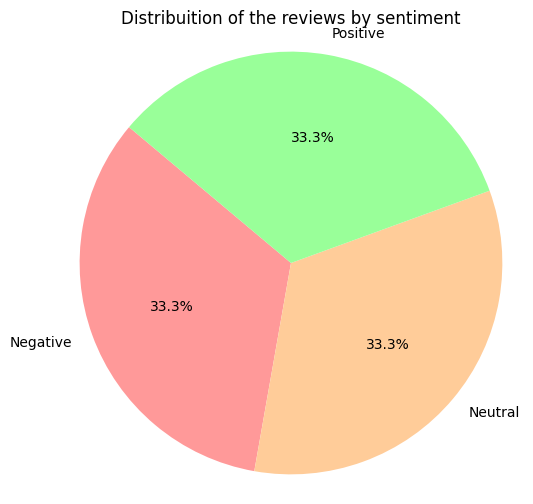

In [ ]:
def plot_label_distribution(dataset):
    # Extracts all the labels from the dataset
    labels = [dataset[i]['labels'].item() for i in range(len(dataset))]

    # Count the occurrences
    counts = Counter(labels)

    # Readable labels
    label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
    sizes = [counts.get(i, 0) for i in range(3)]
    labels_txt = [label_names[i] for i in range(3)]

    # Custom colors
    colors = ['#ff9999', '#ffcc99', '#99ff99']

    # Pie chart
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels_txt, autopct='%1.1f%%', startangle=140, colors=colors)
    plt.axis('equal')
    plt.title("Distribuition of the reviews by sentiment")
    plt.show()

plot_label_distribution(dataset)

### First model

Using epoch strategy because is less expensive respect to steps methods.

- train_dataset
- val_dataset
- early_stopping_patience = 2
- epoch = 5
- batch_size = 32,
- num_workers = 2
- warmup_steps = 500
- weight_decay = 0.01,
- metric_for_best_model = "accuracy"

In [ ]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'First model with overfitting'
metrics_path = MODEL_DIR + 'First model with overfitting metrics.json'
logs_path = MODEL_DIR + 'First model with overfitting logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")

    trainer = definition_hyperparameters(model = model, train_dataset=train_dataset, val_dataset=val_dataset)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

📦 Model already saved at: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/First model with overfitting

📊 Previous metrics per epoch:
epoch_1: {'Training Loss': 0.9536, 'Validation Loss': 0.727925, 'Accuracy': 0.673158, 'F1 Score': 0.674024}
epoch_2: {'Training Loss': 0.7335, 'Validation Loss': 0.682192, 'Accuracy': 0.699474, 'F1 Score': 0.697491}
epoch_3: {'Training Loss': 0.5772, 'Validation Loss': 0.632325, 'Accuracy': 0.725789, 'F1 Score': 0.72468}
epoch_4: {'Training Loss': 0.4228, 'Validation Loss': 0.718325, 'Accuracy': 0.719474, 'F1 Score': 0.720645}
epoch_5: {'Training Loss': 0.2856, 'Validation Loss': 0.81808, 'Accuracy': 0.723158, 'F1 Score': 0.724376}


As we can see the model seems to go overfitting. We need some procedure to regularized.

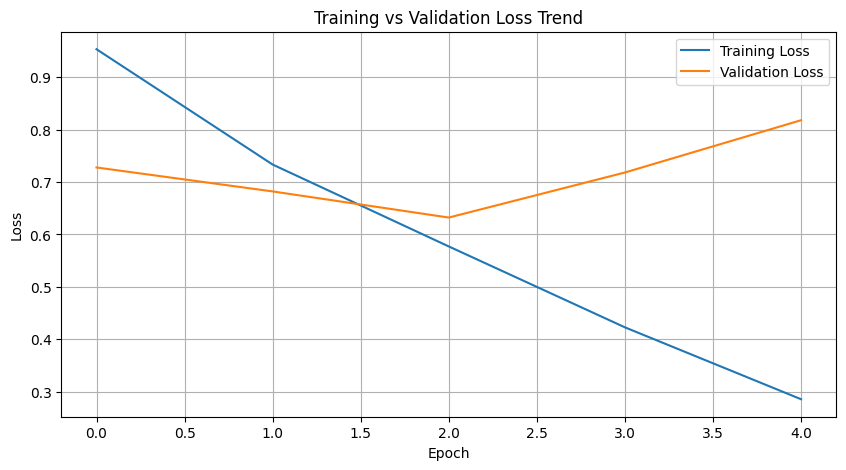

In [ ]:
plot_loss_history(trainer, logs)

 Predicting using loaded Model...

 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.79      0.68      0.73       633
    Neutrale       0.60      0.63      0.61       634
    Positivo       0.76      0.83      0.79       633

    accuracy                           0.71      1900
   macro avg       0.72      0.71      0.71      1900
weighted avg       0.72      0.71      0.71      1900



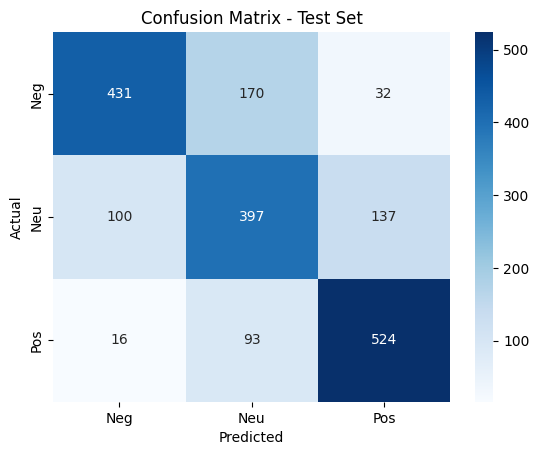

In [ ]:
plot_confusion_matrix_flexible(trainer=trainer, model=model, test_dataset=test_dataset)

## Trying to make the model more generalizable
- Freezing
- Dropout & L2
- More reviews
- More tokens for sentence

### Second Model
- Freezing: 8-12 free (So that is more generalizable and faster)
- More tokens: 128 to 216
- More dataset: 60000 reviews
- weight_decay: 0.01 to 0.05


In [9]:
model_name = 'bert-base-uncased'
tokenizer_freeze = BertTokenizer.from_pretrained(model_name)
model_freeze = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro

# Load the balanced dataset with the reviews to be done
dataset_freeze = BERTJsonDataset(json_file_path, tokenizer_freeze, max_length=216, max_reviews = 60000)

train_dataset, val_dataset, test_dataset = stratified_split_dataset(dataset_freeze)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Dataset built: 60000 balanced reviewed (max for classes: 20000)
Train: 48000 exemples — distribution: {2: 16000, 1: 16000, 0: 16000}
Validation: 6000 exemples — distribution: {1: 2000, 0: 2000, 2: 2000}
Test: 6000 exemples — distribution: {0: 2000, 1: 2000, 2: 2000}

Train: 48000 | Val: 6000 | Test: 6000


In [ ]:
# Unlock only the last 4 layer + classifier
for name, param in model_freeze.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(8, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model_freeze.bert.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

embeddings.word_embeddings.weight: requires_grad=False
embeddings.position_embeddings.weight: requires_grad=False
embeddings.token_type_embeddings.weight: requires_grad=False
embeddings.LayerNorm.weight: requires_grad=False
embeddings.LayerNorm.bias: requires_grad=False
encoder.layer.0.attention.self.query.weight: requires_grad=False
encoder.layer.0.attention.self.query.bias: requires_grad=False
encoder.layer.0.attention.self.key.weight: requires_grad=False
encoder.layer.0.attention.self.key.bias: requires_grad=False
encoder.layer.0.attention.self.value.weight: requires_grad=False
encoder.layer.0.attention.self.value.bias: requires_grad=False
encoder.layer.0.attention.output.dense.weight: requires_grad=False
encoder.layer.0.attention.output.dense.bias: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.weight: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.bias: requires_grad=False
encoder.layer.0.intermediate.dense.weight: requires_grad=False
encoder.layer.

In [ ]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'Second model first try freezing'
metrics_path = MODEL_DIR + 'Second model first try freezing metrics.json'
logs_path = MODEL_DIR + 'Second model first try freezing logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")

    trainer = definition_hyperparameters(model = model_freeze, train_dataset=train_dataset, val_dataset=val_dataset, weight_decay=0.05)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

📦 Model already saved at: /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Second model first try freezing

📊 Previous metrics per epoch:
epoch_1: {'Training Loss': 0.8568, 'Validation Loss': 0.688268, 'Accuracy': 0.691167, 'F1 Score': 0.690821}
epoch_2: {'Training Loss': 0.682, 'Validation Loss': 0.654053, 'Accuracy': 0.703, 'F1 Score': 0.700581}
epoch_3: {'Training Loss': 0.6131, 'Validation Loss': 0.629396, 'Accuracy': 0.726333, 'F1 Score': 0.726357}
epoch_4: {'Training Loss': 0.5618, 'Validation Loss': 0.635972, 'Accuracy': 0.727833, 'F1 Score': 0.724486}
epoch_5: {'Training Loss': 0.5183, 'Validation Loss': 0.641051, 'Accuracy': 0.725333, 'F1 Score': 0.724836}


The Second Model respect to the First Model is less overfitted, but still overfitting.

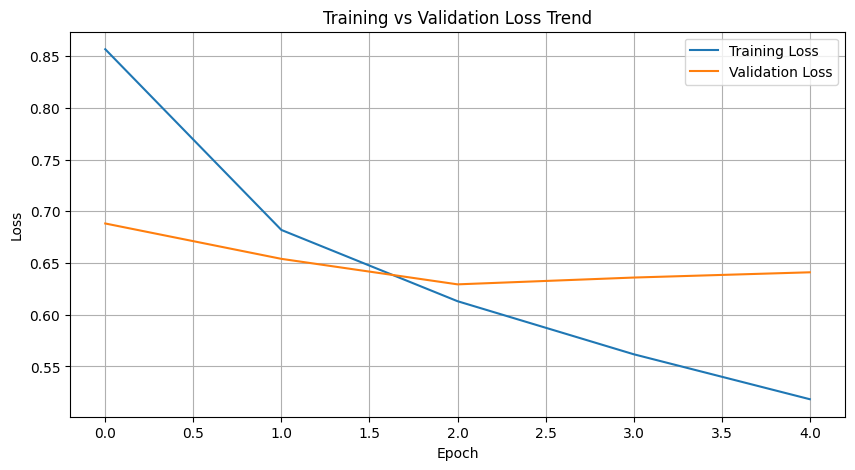

In [ ]:
plot_loss_history(trainer, logs)

 Predicting using loaded Model...

 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.74      0.82      0.78      2000
    Neutrale       0.66      0.58      0.61      2000
    Positivo       0.81      0.81      0.81      2000

    accuracy                           0.74      6000
   macro avg       0.73      0.74      0.73      6000
weighted avg       0.73      0.74      0.73      6000



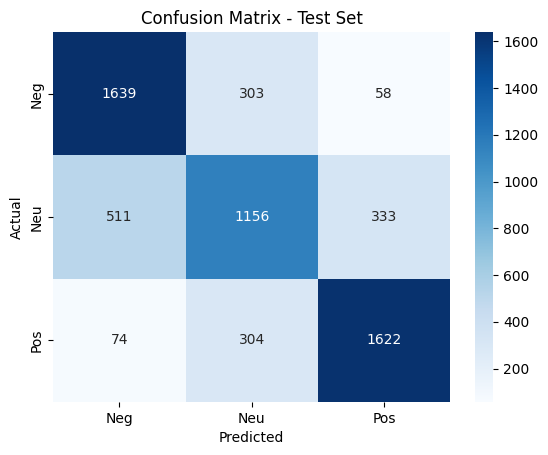

In [ ]:
plot_confusion_matrix_flexible(trainer=trainer, model=model, test_dataset=test_dataset)

### Third model
- learning_rate=2e-5,
- warmup_ratio=0.1
- metric_for_best_model = eval_loss
- lr_scheduler_type = 'cosine'
- greater_is_better = False

In [ ]:
model_freeze_chat = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)
tokenizer_freeze = BertTokenizer.from_pretrained(model_name)

for name, param in model_freeze_chat.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(8, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model_freeze_chat.bert.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


embeddings.word_embeddings.weight: requires_grad=False
embeddings.position_embeddings.weight: requires_grad=False
embeddings.token_type_embeddings.weight: requires_grad=False
embeddings.LayerNorm.weight: requires_grad=False
embeddings.LayerNorm.bias: requires_grad=False
encoder.layer.0.attention.self.query.weight: requires_grad=False
encoder.layer.0.attention.self.query.bias: requires_grad=False
encoder.layer.0.attention.self.key.weight: requires_grad=False
encoder.layer.0.attention.self.key.bias: requires_grad=False
encoder.layer.0.attention.self.value.weight: requires_grad=False
encoder.layer.0.attention.self.value.bias: requires_grad=False
encoder.layer.0.attention.output.dense.weight: requires_grad=False
encoder.layer.0.attention.output.dense.bias: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.weight: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.bias: requires_grad=False
encoder.layer.0.intermediate.dense.weight: requires_grad=False
encoder.layer.

The model didn't converge in this case, should increase the epochs to see how it behaves.

In [ ]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'Third model freezing learning rate'
metrics_path = MODEL_DIR + 'Third model freezing learning rate metrics.json'
logs_path = MODEL_DIR + 'Third model freezing learning rate logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")

    trainer = definition_hyperparameters(model = model_freeze_chat, train_dataset=train_dataset, val_dataset=val_dataset,
                                         weight_decay=0.05, learning_rate = 2e-5, metric_for_best_model = 'eval_loss',
                                         greater_is_better = False, lr_scheduler_type = 'cosine', warmup_ratio=0.1)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

🆕 No existing model found, starting training...


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: l-monti16 (l-monti16-bicoccalumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.920200,0.749814,0.655667,0.656418
2,0.716900,0.702635,0.683667,0.683342
3,0.658700,0.685257,0.705000,0.701137
4,0.619900,0.682233,0.706833,0.704495
5,0.601700,0.676453,0.706833,0.707387


✅ Model saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Third model freezing learning rate
📝 Full training logs saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Third model freezing learning rate logs.json
📊 Metrics summary saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Third model freezing learning rate metrics.json


In [ ]:
print(trainer.args)

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False

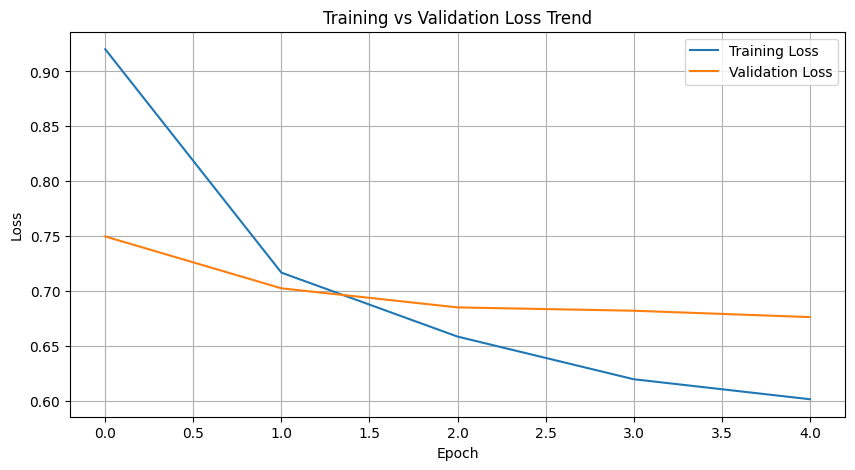

In [ ]:
plot_loss_history(trainer, logs)

 Predicting using Trainer...



 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.74      0.76      0.75      2000
    Neutrale       0.61      0.61      0.61      2000
    Positivo       0.80      0.79      0.80      2000

    accuracy                           0.72      6000
   macro avg       0.72      0.72      0.72      6000
weighted avg       0.72      0.72      0.72      6000



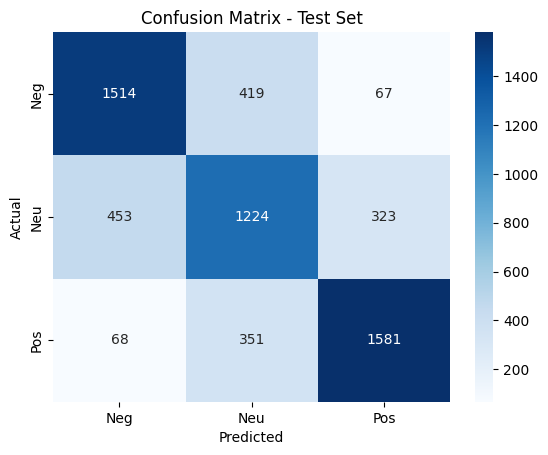

In [ ]:
plot_confusion_matrix_flexible(trainer=trainer, model=model, test_dataset=test_dataset)

### Strategy
After the various hyperparameters, we will try to see if, through a bit of formatting and cleaning the performance increases.

In [7]:
json_file_path_clean = '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/reviews_clean.json'

In [8]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model_strategy = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro

# Load the balanced dataset with the reviews to be done
dataset_strategy1 = BERTJsonDataset(json_file_path_clean, tokenizer, max_length=216, max_reviews = 60000)

sample = dataset_strategy1[0]
print("Lunghezza dei token:", len(sample['input_ids']))

train_dataset, val_dataset, test_dataset = stratified_split_dataset(dataset_strategy1)
print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Dataset built: 60000 balanced reviewed (max for classes: 20000)
Lunghezza dei token: 216
Train: 48000 exemples — distribution: {2: 16000, 1: 16000, 0: 16000}
Validation: 6000 exemples — distribution: {1: 2000, 0: 2000, 2: 2000}
Test: 6000 exemples — distribution: {0: 2000, 1: 2000, 2: 2000}

Train: 48000 | Val: 6000 | Test: 6000


In [ ]:
for name, param in model_strategy.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(8, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model_strategy.bert.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

embeddings.word_embeddings.weight: requires_grad=False
embeddings.position_embeddings.weight: requires_grad=False
embeddings.token_type_embeddings.weight: requires_grad=False
embeddings.LayerNorm.weight: requires_grad=False
embeddings.LayerNorm.bias: requires_grad=False
encoder.layer.0.attention.self.query.weight: requires_grad=False
encoder.layer.0.attention.self.query.bias: requires_grad=False
encoder.layer.0.attention.self.key.weight: requires_grad=False
encoder.layer.0.attention.self.key.bias: requires_grad=False
encoder.layer.0.attention.self.value.weight: requires_grad=False
encoder.layer.0.attention.self.value.bias: requires_grad=False
encoder.layer.0.attention.output.dense.weight: requires_grad=False
encoder.layer.0.attention.output.dense.bias: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.weight: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.bias: requires_grad=False
encoder.layer.0.intermediate.dense.weight: requires_grad=False
encoder.layer.

In [ ]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'First model clean reviews'
metrics_path = MODEL_DIR + 'First model clean reviews metrics.json'
logs_path = MODEL_DIR + 'First model clean reviews logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")

    trainer = definition_hyperparameters(model = model_strategy, train_dataset=train_dataset, val_dataset=val_dataset,
                                         weight_decay=0.05, learning_rate = 2e-5, metric_for_best_model = 'eval_loss',
                                         greater_is_better = False, lr_scheduler_type = 'cosine', warmup_ratio=0.1, early_stopping_patience = 3)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

🆕 No existing model found, starting training...


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: l-monti16 (l-monti16-bicoccalumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.922100,0.765964,0.661500,0.659739
2,0.717900,0.690861,0.693333,0.691404
3,0.659100,0.671527,0.712667,0.711305
4,0.623300,0.663907,0.717167,0.714822
5,0.603300,0.661034,0.719833,0.719746


✅ Model saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/First model clean reviews
📝 Full training logs saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/First model clean reviews logs.json
📊 Metrics summary saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/First model clean reviews metrics.json


In [ ]:
print(trainer.args)

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False

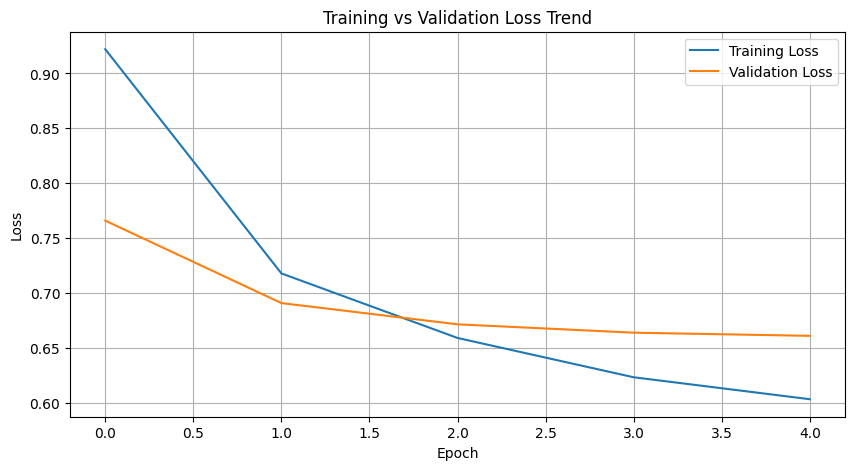

In [ ]:
plot_loss_history(trainer, logs)

 Predicting using Trainer...



 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.75      0.75      0.75      2000
    Neutrale       0.60      0.61      0.60      2000
    Positivo       0.80      0.79      0.79      2000

    accuracy                           0.72      6000
   macro avg       0.72      0.72      0.72      6000
weighted avg       0.72      0.72      0.72      6000



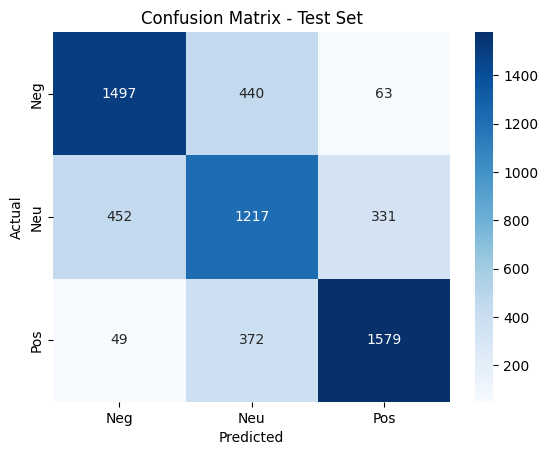

In [ ]:
plot_confusion_matrix_flexible(trainer=trainer, model=model, test_dataset=test_dataset)

There is a little upgrade compared to the previous dataset without the cleaning

### Strategy 2
We add some layer to train:
- Freezing: 6-12 free

In [ ]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model_strategy = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro

for name, param in model_strategy.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(6, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'Second model clean reviews'
metrics_path = MODEL_DIR + 'Second model clean reviews metrics.json'
logs_path = MODEL_DIR + 'Second model clean reviews logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")

    trainer = definition_hyperparameters(model = model_strategy, train_dataset=train_dataset, val_dataset=val_dataset,
                                         weight_decay=0.05, learning_rate = 2e-5, metric_for_best_model = 'eval_loss',
                                         greater_is_better = False, lr_scheduler_type = 'cosine', warmup_ratio=0.1, early_stopping_patience = 3)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

🆕 No existing model found, starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.895700,0.709140,0.680333,0.679407
2,0.682400,0.656195,0.714667,0.715243
3,0.611800,0.641129,0.728167,0.727113
4,0.563700,0.630508,0.735000,0.733091
5,0.535600,0.631048,0.739000,0.739521


✅ Model saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Second model clean reviews
📝 Full training logs saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Second model clean reviews logs.json
📊 Metrics summary saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Second model clean reviews metrics.json


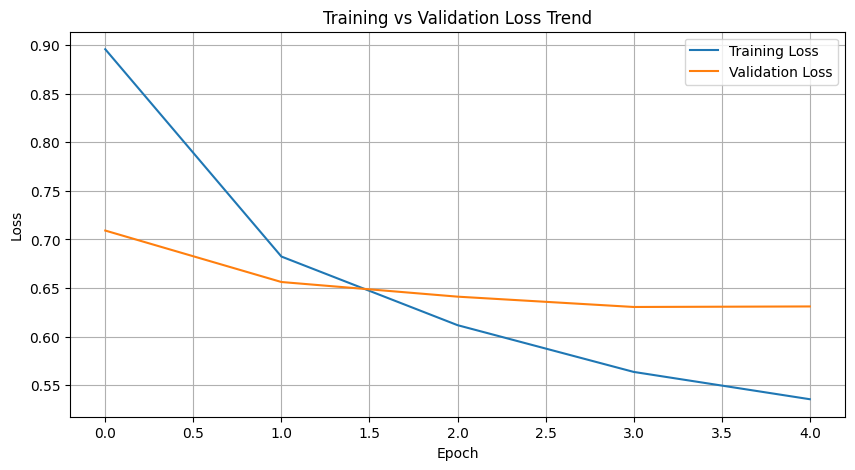

In [ ]:
plot_loss_history(trainer, logs)

 Predicting using Trainer...



 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.74      0.77      0.76      2000
    Neutrale       0.63      0.59      0.61      2000
    Positivo       0.80      0.82      0.81      2000

    accuracy                           0.73      6000
   macro avg       0.72      0.73      0.73      6000
weighted avg       0.72      0.73      0.73      6000



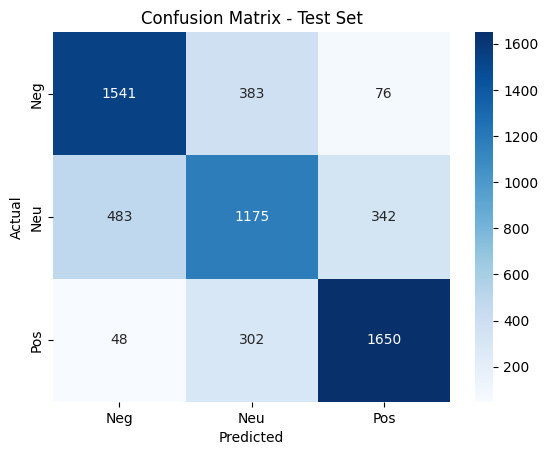

In [ ]:
plot_confusion_matrix_flexible(trainer=trainer, model=model, test_dataset=test_dataset)

### Strategy 3
The model shows a tendency to overfit, likely because we gave it more flexibility by unfreezing layers 6 through 12, compared to the previous setup where we only trained layers 8 through 12. To address this, we will increase regularization to observe how this impacts the training dynamics.

- Dropout 0.3
- weight_decay=0.1
- learning_rate=3e-5

In [ ]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model_strategy = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro
model_strategy.config.hidden_dropout_prob = 0.3  # dropout

for name, param in model_strategy.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(6, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'Third model clean reviews'
metrics_path = MODEL_DIR + 'Third model clean reviews metrics.json'
logs_path = MODEL_DIR + 'Third model clean reviews logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")
    trainer = definition_hyperparameters(model = model_strategy, train_dataset=train_dataset, val_dataset=val_dataset,
                                         weight_decay=0.15, learning_rate = 2e-5, metric_for_best_model = 'eval_loss',
                                         greater_is_better = False, lr_scheduler_type = 'cosine', warmup_ratio=0.1, early_stopping_patience = 3)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

🆕 No existing model found, starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.836600,0.691534,0.690333,0.690802
2,0.661600,0.638716,0.715833,0.717504
3,0.584800,0.624267,0.734333,0.733438
4,0.524000,0.624327,0.749167,0.747502
5,0.483400,0.629300,0.746333,0.746966


✅ Model saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Third model clean reviews
📝 Full training logs saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Third model clean reviews logs.json
📊 Metrics summary saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Third model clean reviews metrics.json


In [ ]:
print(trainer.args)

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=False

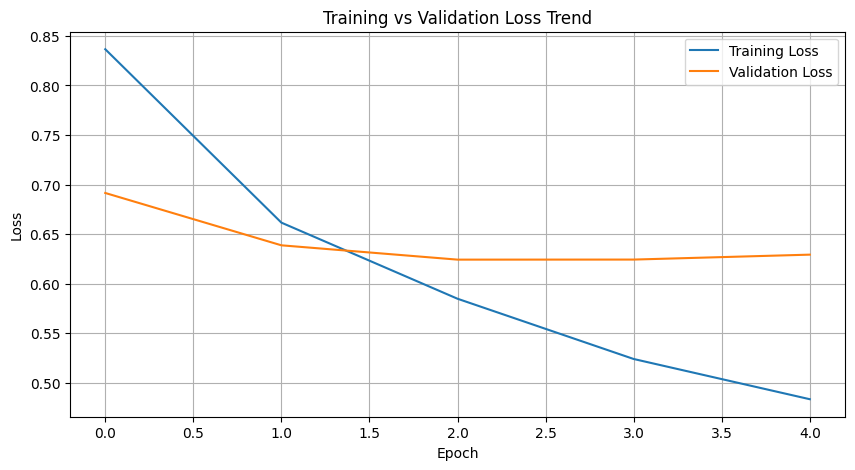

In [ ]:
plot_loss_history(trainer, logs)

 Predicting using Trainer...



 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.78      0.72      0.75      2000
    Neutrale       0.62      0.62      0.62      2000
    Positivo       0.78      0.84      0.81      2000

    accuracy                           0.73      6000
   macro avg       0.73      0.73      0.73      6000
weighted avg       0.73      0.73      0.73      6000



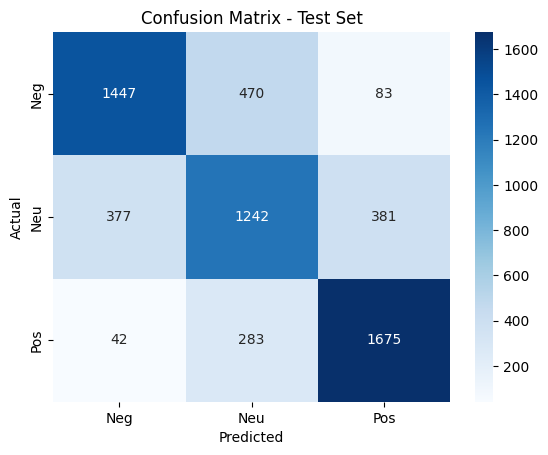

In [ ]:
plot_confusion_matrix_flexible(trainer=trainer, model=model, test_dataset=test_dataset)

We observe that validation loss and accuracy improve as the model depth increases, indicating a benefit to adding layers. However, beyond a certain point the additional layers lead to increasing overfitting. This behavior may reflect a systematic bias that limits further gains despite the preprocessing applied.

### Strategy 4

Use the relevant dataset to evaluate whether the model performs better on the newly created dataset and on the real-world dataset. Then we will usign the Relevant_dataset with the body adjusted and in validation and test we are using the real reviews.

In [10]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)

# Load the balanced dataset with the reviews to be done
dataset = BERTJsonDataset(RELEVANT_PATH, tokenizer, max_length=256, max_reviews = 60000)

train_dataset, val_dataset_not_used, test_dataset_not_used = stratified_split_dataset(dataset)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

✅ Dataset built: 60000 balanced reviewed (max for classes: 20000)
Train: 48000 exemples — distribution: {2: 16000, 1: 16000, 0: 16000}
Validation: 6000 exemples — distribution: {1: 2000, 0: 2000, 2: 2000}
Test: 6000 exemples — distribution: {0: 2000, 1: 2000, 2: 2000}

Train: 48000 | Val: 6000 | Test: 6000


In [11]:
model_strategy_4 = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro
model_strategy_4.config.hidden_dropout_prob = 0.3  # dropout

for name, param in model_strategy_4.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(6, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
# Define paths for saving model and metrics
model_path = MODEL_DIR + 'Fourth model clean reviews'
metrics_path = MODEL_DIR + 'Fourth model clean reviews metrics.json'
logs_path = MODEL_DIR + 'Fourth model clean reviews logs.json'

trainer = None
logs = None
model = None

# Check if the model already exists
if os.path.exists(model_path):
    print(f"📦 Model already saved at: {model_path}")
    model = BertForSequenceClassification.from_pretrained(model_path)

    # Load and print previous metrics if available
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        print("\n📊 Previous metrics per epoch:")
        for epoch, result in metrics.items():
            print(f"{epoch}: {result}")
    else:
        print("⚠️ No saved metrics found.")

    # Load training logs (for plotting)
    if os.path.exists(logs_path):
        with open(logs_path, "r") as f:
            logs = json.load(f)
    else:
        print("⚠️ No saved logs found for plotting.")

else:
    print("🆕 No existing model found, starting training...")
    trainer = definition_hyperparameters(model = model_strategy_4, train_dataset=train_dataset, val_dataset=val_dataset, epoch = 7,
                                         weight_decay=0.15, learning_rate = 2e-5, metric_for_best_model = 'eval_loss',
                                         greater_is_better = False, lr_scheduler_type = 'cosine', warmup_ratio=0.1, early_stopping_patience = 3)
    trainer.train()

    # Save the trained model
    trainer.save_model(model_path)
    print(f"✅ Model saved at {model_path}")

    # Collect full logs
    full_logs = trainer.state.log_history

    # Save logs for plotting
    with open(logs_path, "w") as f:
        json.dump(full_logs, f, indent=4)

    print(f"📝 Full training logs saved at {logs_path}")

    # Process metrics per epoch
    metrics_per_epoch = {}
    current_epoch = 0
    summary = {}

    for entry in full_logs:
        if 'epoch' in entry:
            current_epoch = int(entry['epoch'])

        if 'loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Training Loss'] = round(entry['loss'], 6)

        if 'eval_loss' in entry:
            summary[f"epoch_{current_epoch}"] = summary.get(f"epoch_{current_epoch}", {})
            summary[f"epoch_{current_epoch}"]['Validation Loss'] = round(entry['eval_loss'], 6)

        if 'eval_accuracy' in entry:
            summary[f"epoch_{current_epoch}"]['Accuracy'] = round(entry['eval_accuracy'], 6)

        if 'eval_f1' in entry:
            summary[f"epoch_{current_epoch}"]['F1 Score'] = round(entry['eval_f1'], 6)

    # Save metrics summary
    with open(metrics_path, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"📊 Metrics summary saved at {metrics_path}")

    logs = full_logs

🆕 No existing model found, starting training...


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: l-monti16 (l-monti16-bicoccalumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.906000,0.706570,0.685000,0.680058
2,0.684000,0.634315,0.722333,0.719063
3,0.614700,0.619203,0.736833,0.735623
4,0.561700,0.594232,0.751167,0.750404
5,0.515100,0.609245,0.753167,0.750589
6,0.483000,0.608829,0.755500,0.754995
7,0.465500,0.615146,0.755333,0.754666


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packa

✅ Model saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Fourth model clean reviews
📝 Full training logs saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Fourth model clean reviews logs.json
📊 Metrics summary saved at /content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/Models/Fourth model clean reviews metrics.json


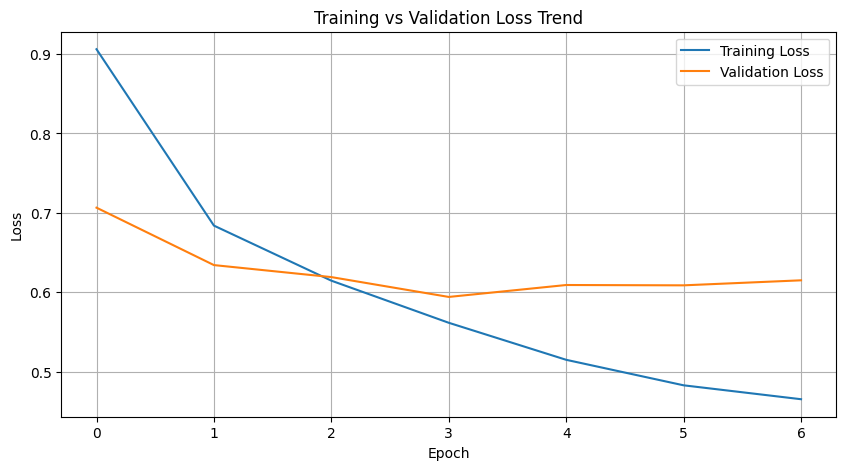

In [13]:
plot_loss_history(trainer, logs)

 Predicting using Trainer...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



 Classification Report:
              precision    recall  f1-score   support

    Negativo       0.77      0.76      0.77      2000
    Neutrale       0.65      0.65      0.65      2000
    Positivo       0.81      0.83      0.82      2000

    accuracy                           0.74      6000
   macro avg       0.74      0.74      0.74      6000
weighted avg       0.74      0.74      0.74      6000



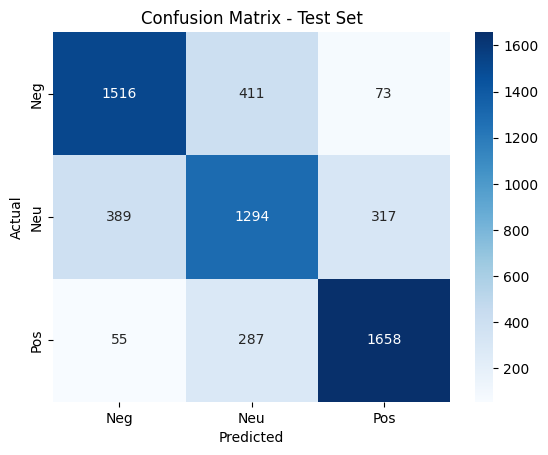

In [15]:
plot_confusion_matrix_flexible(trainer=trainer, model=model_strategy_4, test_dataset=test_dataset)

VEDERE SE TOGLIERE

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    dataloader_num_workers=4,
    warmup_steps=500,
    weight_decay=0.05,
    logging_dir='./logs',
    eval_strategy ="epoch",          # evaluation for each epoch
    logging_strategy="epoch",        # logging for each epoch
    save_strategy="epoch",           # save for each epoch
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",  # or "f1", "eval_loss" ecc.
    greater_is_better=True,
    fp16=True
)

trainer = Trainer(
    model=model_strategy,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.848300,0.703954,0.679833,0.681978
2,0.683200,0.681503,0.699833,0.696451
3,0.621300,0.640955,0.718167,0.720254
4,0.573500,0.667196,0.720833,0.718309
5,0.535000,0.648457,0.726000,0.727180


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: T

TrainOutput(global_step=7500, training_loss=0.6522565348307292, metrics={'train_runtime': 1427.2397, 'train_samples_per_second': 168.157, 'train_steps_per_second': 5.255, 'total_flos': 2.664023354496e+16, 'train_loss': 0.6522565348307292, 'epoch': 5.0})

In [ ]:
model_strategy = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 per sentiment: pos, neg, neutro

for name, param in model_strategy.bert.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(8, 12)) or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

for name, param in model_strategy.bert.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


embeddings.word_embeddings.weight: requires_grad=False
embeddings.position_embeddings.weight: requires_grad=False
embeddings.token_type_embeddings.weight: requires_grad=False
embeddings.LayerNorm.weight: requires_grad=False
embeddings.LayerNorm.bias: requires_grad=False
encoder.layer.0.attention.self.query.weight: requires_grad=False
encoder.layer.0.attention.self.query.bias: requires_grad=False
encoder.layer.0.attention.self.key.weight: requires_grad=False
encoder.layer.0.attention.self.key.bias: requires_grad=False
encoder.layer.0.attention.self.value.weight: requires_grad=False
encoder.layer.0.attention.self.value.bias: requires_grad=False
encoder.layer.0.attention.output.dense.weight: requires_grad=False
encoder.layer.0.attention.output.dense.bias: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.weight: requires_grad=False
encoder.layer.0.attention.output.LayerNorm.bias: requires_grad=False
encoder.layer.0.intermediate.dense.weight: requires_grad=False
encoder.layer.

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=7,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    lr_scheduler_type="cosine",
    dataloader_num_workers=2,
    warmup_ratio=0.1,
    weight_decay=0.05,
    logging_dir='./logs',
    eval_strategy ="epoch",          # evaluation for each epoch
    logging_strategy="epoch",        # logging for each epoch
    save_strategy="epoch",           # save for each epoch
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",  # or "f1", "eval_loss" ecc.
    greater_is_better=False,
    fp16=True
)

trainer = Trainer(
    model=model_strategy,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: l-monti16 (l-monti16-bicoccalumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.930200,0.783478,0.647000,0.642022
2,0.722200,0.681373,0.699167,0.699119
3,0.662200,0.660598,0.712833,0.714611
4,0.623400,0.647086,0.719333,0.717731
5,0.592300,0.652401,0.717833,0.718261
6,0.573100,0.648939,0.721000,0.720929


TrainOutput(global_step=9000, training_loss=0.683889641655816, metrics={'train_runtime': 1673.0099, 'train_samples_per_second': 200.836, 'train_steps_per_second': 6.276, 'total_flos': 3.1968280253952e+16, 'train_loss': 0.683889641655816, 'epoch': 6.0})

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=7,
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    lr_scheduler_type="cosine",
    dataloader_num_workers=2,
    warmup_ratio=0.1,
    weight_decay=0.05,
    logging_dir='./logs',
    eval_strategy ="epoch",          # evaluation for each epoch
    logging_strategy="epoch",        # logging for each epoch
    save_strategy="epoch",           # save for each epoch
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",  # or "f1", "eval_loss" ecc.
    greater_is_better=False,
    fp16=True
)

trainer = Trainer(
    model=model_strategy,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.901400,0.732111,0.674167,0.671458
2,0.706200,0.663370,0.709000,0.707685
3,0.643300,0.650406,0.717500,0.720577
4,0.592800,0.625878,0.727333,0.725752
5,0.545100,0.643353,0.729167,0.728560
6,0.509100,0.641594,0.729167,0.729332
7,0.483700,0.649364,0.728333,0.729165


TrainOutput(global_step=10500, training_loss=0.6259601469494047, metrics={'train_runtime': 1865.2952, 'train_samples_per_second': 180.132, 'train_steps_per_second': 5.629, 'total_flos': 3.7296326962944e+16, 'train_loss': 0.6259601469494047, 'epoch': 7.0})

## BERT tuning for specific tasks

Pre-processing and salvataggio a blocchi
Nel codice attuale:

Le recensioni non valide (es. senza testo o rating) vengono scartate

Quindi, l’indice 100 nel JSON può corrispondere a un record scartato

Nei blocchi salvati (block_0.pt, block_1.pt, ecc.), solo recensioni valide sono conservate



In [ ]:
def train_on_block(block_path, model_name='bert-base-uncased', num_labels=3, output_model_dir="./model_block"):

    data = torch.load(block_path)
    dataset = StaticTensorDataset(data)

    model = BertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    training_args = TrainingArguments(
        output_dir=output_model_dir,
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        evaluation_strategy="no",
        save_strategy="no",
        logging_steps=10,
        logging_dir='./logs',
        learning_rate=2e-5
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset
    )

    trainer.train()
    model.save_pretrained(output_model_dir)
    print(f"✅ Modello salvato in: {output_model_dir}")

In [ ]:
train_on_block(os.path.join(OUTPUT_DIR, 'block_0.pt'), output_model_dir="./bert_trained_block_0")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/processed_blocks/block_0.pt'

Per iterare su ogni blocco

In [ ]:
for i in range(num_blocchi):
    path = os.path.join(OUTPUT_DIR, f"block_{i}.pt")
    train_on_block(path, output_model_dir=f"./bert_block_{i}")

First step tokenize the dataset

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-cased")
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

#We select smaller subsets of the training and testing data:
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = dataset["test"].shuffle(seed=42).select(range(1000))

small_train_dataset = small_train_dataset.map(tokenize_function, batched=True) #The .map() method applies the specified function (tokenize_function) to each example in the dataset.
small_eval_dataset = small_eval_dataset.map(tokenize_function, batched=True)

In [ ]:
print(small_train_dataset)

print(f"{small_train_dataset['text'][0] = }")
print(f"{small_train_dataset['label'][0] = }")
print(f"{small_train_dataset['input_ids'][0] = }") #BERT token IDs
print(f"{small_train_dataset['attention_mask'][0] = }") #prints the attention_mask for the first example. The attention mask is a binary tensor (containing 0s and 1s) that tells the model which tokens to pay attention to and which to ignore.

We want to use the same model with a classification head. A classification head takes the CLS token embedding and uses a linear layer to classify the sentence embedding to a fixed number of labels.

In [ ]:
#we download and load the pre-trained bert-base-cased model and configure it for a classification task with 5 output classes.
model = AutoModelForSequenceClassification.from_pretrained(
    "google-bert/bert-base-cased",
    num_labels=5,
)

In [ ]:
training_args = TrainingArguments(
    # output_dir="test_trainer",
    per_device_train_batch_size=12,
    per_device_eval_batch_size=12,
    learning_rate=5e-5,
    num_train_epochs=3,
    eval_strategy="epoch",
    # and many more ...
    report_to="none",
)

We also want to evaluate the model according to a specific metric. The obviuous (and simple) choice for a classification task is accuracy

In [ ]:
import evaluate

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1) #calculates the predicted class for each example. The np.argmax function finds the index of the maximum value along the last axis (axis=-1) of the logits array. This index corresponds to the class with the highest predicted probability.
    return metric.compute(predictions=predictions, references=labels) #It compares the predictions made by the model to the true references (the labels) and returns the accuracy score.

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true" #This small code snippet is used to disable WandB (Weights & Biases) logging.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
) #We are setting up the Trainer with everything it needs to train and evaluate the BERT model on our specific task and data.


trainer.train()

We can now inference the model to check if the prediction are correct

In [ ]:
#This code demonstrates how to use the fine-tuned BERT model to make a prediction on a single piece of text.

input = tokenizer('Very bad restaurant. Do not go there!', return_tensors='pt')
for k in input:
    input[k] = input[k].to('cuda')

output = model(**input) # input tensors are passed to the model
predictions = output.logits #Logits are the raw, unnormalized scores output by the model before the final activation function (like softmax)

print(predictions)
label_predicted = predictions.argmax(-1) #This index corresponds to the class with the highest predicted probability, which is the model's predicted label for the input text
print('The predicted score is:', label_predicted.item())

In [ ]:
#This function is designed to streamline the process of getting a prediction from your trained classification model for a given input text.

def get_prediction_label(input_text, model):
    input = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True)
    for k in input:
        input[k] = input[k].to('cuda')

    output = model(**input)
    predicted = output.logits.argmax(-1)

    return predicted.item()

get_prediction_label("Very good hamburger but staff was not friendly", model)